# Notebook 01 — Spatial Objects and Composition

## Overview

This notebook introduces the fundamental building blocks of OWL ontology engineering using the pizza domain as a running example. We ground our pizza classes in SULO's `SpatialObject` hierarchy and progressively build up a part-whole model of a pizza — from declaring the first classes to reasoning automatically over defined, closed class expressions.

Along the way we encounter two important OWL engineering constraints — the restriction on cardinality over transitive properties, and the Open World Assumption — and learn the SULO design patterns that address them.

## Learning Objectives

By the end of this notebook you will be able to:

- Declare OWL `Class` and `Individual` entities and organise them with `SubClassOf` axioms grounded in `sulo:SpatialObject`
- Choose between `some`, `min`, `max`, and `exactly` cardinality restrictions to express a given compositional requirement
- Explain why cardinality restrictions cannot be placed on transitive properties, and use `hasDirectPart` as the SULO-recommended alternative
- Query inferred part chains using the `INDIRECT_` prefix in owlready2, and predict which classes appear based on transitivity
- Define classes using `equivalent_to` expressions to enable automated classification by the reasoner
- Explain the Open World Assumption and close a class definition using `AllDisjoint` and the universal restriction (`only`)


The following cell will load the tutorial helper functions, define our new pizza ontology, and load the SULO ontology.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *

# Create our pizza ontology and import SULO
base_iri = "https://w3id.org/ontostart/pizza/"
pizza = get_ontology(base_iri)
# add some metadata about the ontology
pizza.comment = "An ontology about pizzas using SULO."

# save this file
os.makedirs("dist", exist_ok=True)
pizza.save("dist/pizza.owl", format="rdfxml")

# load the SULO ontology and add it to the pizza ontology
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()
print("Loaded SULO:", sulo.base_iri)
pizza.imported_ontologies.append(sulo)

Loaded SULO: https://w3id.org/sulo/


# The nature and composition of a pizza

A pizza is traditionally a dish of Italian origin, consisting of a flat round base of baked dough covered with tomato-based sauce and optionally herbs, cheese, meat, fish, and/or vegetables.

In OWL, the term `pizza` corresponds to a `Class` — a set of individuals sharing particular attributes. We will style class names in CamelCase: `Pizza`.

`Pizza`, `PizzaCrust`, `PizzaSauce` are all kinds of food material, and food materials are kinds of `SpatialObject`. Grounding our classes in `sulo:SpatialObject` is not just a formality - it carries specific semantics: spatial objects persist through time, can gain and lose parts, change qualities, and are wholly present at each moment of their lifetime. A pizza satisfies all of these: it endures from assembly to consumption, its toppings can be added or removed, its temperature changes in the oven, and it is wholly present at each moment.


Let's now formalise our ontology using OwlReady2. We make class declarations and define our first `SubClassOf` axioms such that every instance of a subclass is necessarily an instance of a parent class. 

In [2]:
# let's start with a top level category called FoodMaterial to define a pizza and its parts
with pizza:
    class FoodMaterial(sulo.SpatialObject):
        label = "food material"
        comment = """A food material is a spatial object that is intended for consumption as food."""
    
    class Pizza(FoodMaterial):
        label = [locstr("pizza", "en")]
        comment = """A pizza is a food material minimally consisting of a pizza crust (baked dough) and optionally topped with 
                    tomatoes or tomato sauce, cheese, and often various other ingredients (such as anchovies, mushrooms, onions, olives, 
                    vegetables, meat, etc.) baked at a high temperature."""

    class PizzaCrust(FoodMaterial):
        label = [locstr("pizza crust", "en")]
        comment = [locstr("""A pizza crust is a food material resulting from the cooking of a dough 
                    and forms the base of a pizza upon which sauce and toppings are added.""", "en")]

Next, let's check the subclasses of `FoodMaterial`, and then the ancestors of `Pizza`

In [3]:
print("Pizza parent class", Pizza.is_a)
print("Pizza ancestors:", [c.name for c in Pizza.ancestors()])
print("FoodMaterial children classes:", list(FoodMaterial.subclasses()))

Pizza parent class [pizza.FoodMaterial]
Pizza ancestors: ['Object', 'SpatialObject', 'FoodMaterial', 'Pizza', 'Thing']
FoodMaterial children classes: [pizza.Pizza, pizza.PizzaCrust]


### **YOUR TURN: Add a new Class**
Add a new class called `PizzaSauce` that is a subclass of `FoodMaterial`. Create a new English-language definition "A pizza sauce is a food material used in the preparation of pizza, typically made from tomatoes and various herbs and spices". 


In [4]:
# YOUR TURN: write your solution here


In [5]:
# assert FoodMaterial in PizzaSauce.ancestors(), "PizzaSauce should be a subclass of FoodMaterial"

In [6]:
#print('PizzaSauce definition: '+' '.join(PizzaSauce.comment.en.first().split()))

### **Composition: `hasPart`**
SULO defines `hasPart` as a fundamental relation between wholes and their parts. A part meaningfully contributes to the whole's existence, structure, or function. `hasPart` is defined with the computational properties of being transitive and reflexive:

**Transitive** — if A has-part B, and B has-part C, then A has-part C. A pizza has-part a crust; a crust has-part a cornicione; therefore a pizza has-part a cornicione.

**Reflexive** — a reflexive property holds between every individual and itself — x `hasPart` x for all x. In other words, every thing is considered a part of itself.


In [7]:
# examine the object property characteristics
for prop in [sulo.hasPart]:
    chars = [c.__name__ for c in prop.is_a ]
    print(f"{prop.name}: {chars}")

hasPart: ['ObjectProperty', 'ReflexiveProperty', 'TransitiveProperty', 'contains']


One of the most important parts of a pizza is the `PizzaCrust`. Every pizza must have a crust, and there can be no pizza without a crust. We formalize this in OWL by adding a `SubClassOf` axiom to `Pizza` using an existential restriction on the `hasPart` property towards `PizzaCrust`. 
 

### Cardinality restrictions

A **cardinality restriction** constrains how many individuals of a given class can fill a property slot. OWL provides four forms, all available as owlready2 methods on any property:

| Restriction | OWL syntax | Meaning |
|---|---|---|
| `prop.some(C)` | `∃ prop.C` | at least one C (existential) |
| `prop.min(n, C)` | `≥ n prop.C` | at least *n* instances of C |
| `prop.max(n, C)` | `≤ n prop.C` | at most *n* instances of C |
| `prop.exactly(n, C)` | `= n prop.C` | exactly *n* instances of C |

**Applying these to `Pizza` and `PizzaCrust`**

The question is: how many crusts does a pizza have? Here is what each choice would commit us to, and whether it captures the intended meaning:

- `hasDirectPart.some(PizzaCrust)` — *at least one crust, no upper bound.* A pizza with three crusts satisfies this. This is the right choice when the upper bound is genuinely unknown or unbounded, but for a pizza it is too permissive.

- `hasDirectPart.min(1, PizzaCrust)` — semantically equivalent to `some(PizzaCrust)` when n = 1. Same permissiveness.

- `hasDirectPart.max(1, PizzaCrust)` — *at most one crust, possibly none.* This allows a crust-free pizza, which is not a pizza at all. On its own it is the wrong choice.

- `hasDirectPart.exactly(1, PizzaCrust)` — *exactly one crust, no more, no less.* This captures the intended identity condition: a pizza that has no crust is not a pizza, and a pizza that has two crusts stacked is something else. This is the axiom we will use.

`min` and `max` become useful when the domain genuinely has only one bound — for example, a `LoadedPizza` might require *at least* three toppings without capping them, or a `PersonalPizza` might allow *at most* two. We will see both later. For the pizza–crust relationship the symmetric `exactly(1)` is the right choice.


In [8]:
with pizza:
    Pizza.is_a.append(sulo.hasPart.exactly(1,PizzaCrust))

Next, let's run the automated reasoner to make sure that our ontology is consistent.

In [9]:
ret = safe_call_reasoner(pizza)
if not ret["ok"]:
    print("Reasoner error:", ret["error"])
else:
    print("Ontology consistent:", ret["ok"])
    print("Inconsistent classes:", ret["inconsistent"])

Reasoner error: Non-simple property '<https://w3id.org/sulo/hasPart>' or its inverse appears in the cardinality restriction 'ObjectMaxCardinality(1 <https://w3id.org/sulo/hasPart> <https://w3id.org/ontostart/pizza/PizzaCrust>)'.


The reasoner error tells us something important about OWL DL: **cardinality restrictions cannot be placed on transitive properties**. This is not a bug. It is a deliberate constraint to preserve decidability.

SULO anticipated this. It provides `hasDirectPart` as a **non-transitive sub-property of `hasPart`** precisely so that ontology engineers can write cardinality restrictions on part-whole relations. Using `hasDirectPart` instead of `hasPart` in a restriction does not sacrifice any inference: because `hasDirectPart ⊑ hasPart`, every `hasDirectPart` assertion entails a `hasPart` assertion, and `INDIRECT_hasPart` queries will still traverse the full part chain.

This is a deliberate **SULO design pattern**.

Let's replace `hasPart` with `hasDirectPart` and confirm the sub-property relationship in code.

In [10]:
with pizza:
      Pizza.is_a.remove(sulo.hasPart.exactly(1, PizzaCrust))
#confirm that it was removed
Pizza.is_a

[pizza.FoodMaterial]

In [11]:
# Confirm hasDirectPart is a sub-property of hasPart
print("hasDirectPart is_a:", [p.name for p in sulo.hasDirectPart.is_a if hasattr(p, 'name')])
print("hasDirectPart ⊑ hasPart:", sulo.hasPart in sulo.hasDirectPart.is_a)
print("hasDirectPart is transitive:", TransitiveProperty in sulo.hasDirectPart.is_a)

hasDirectPart is_a: ['ObjectProperty', 'hasPart']
hasDirectPart ⊑ hasPart: True
hasDirectPart is transitive: False


In [12]:
# and now add the new axiom that uses hasDirectPart
with pizza:
    Pizza.is_a.append(sulo.hasDirectPart.exactly(1, PizzaCrust))

In [13]:
# confirmed it was added 
Pizza.is_a

[pizza.FoodMaterial, sulo.hasDirectPart.exactly(1, pizza.PizzaCrust)]

In [14]:
result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


Let's now check that `PizzaCrust` is a direct part of a pizza:

In [15]:
Pizza.hasDirectPart

[pizza.PizzaCrust]

### **YOUR TURN: Add PizzaSauce as a part**

Every pizza needs more than just a crust — it also needs a sauce. Add a subclass axiom that states that every pizza has some pizza sauce.
Modify `Pizza.is_a` to require `sulo.hasDirectPart.some(PizzaSauce)`. Run the reasoner, then call `Pizza.INDIRECT_hasPart`.

> Does `PizzaSauce` appear alongside `PizzaCrust`? What do they have in common that makes both show up?

In [16]:
Pizza.hasDirectPart

[pizza.PizzaCrust]

### **Parthood Transitivity**
The outer edge of the pizza crust is referred to as the `Cornicione`. Let's add this class to the ontology, as well as the fact that every crust has a cornicione as a part.

In [17]:
with pizza:
    class Cornicione(FoodMaterial):
        label = [locstr("cornicione", "en")]
        comment = """A cornicione is the outer edge of a pizza crust"""
    
    PizzaCrust.is_a.append(sulo.hasDirectPart.some(Cornicione))

In [18]:
PizzaCrust.hasDirectPart

[pizza.Cornicione]

Since `hasDirectPart` is a sub-property of `hasPart`, a query to retrieve the `hasPart` relations will also retrieve the `hasDirectPart` relations.

Using owlready2, we prefix the relation with `INDIRECT_` to get the inferred relation.

Now, we should be able to query the ontology for all the parts of a pizza, which should be the `PizzaCrust` and the `Cornicione`.

In [19]:
Pizza.INDIRECT_hasPart

[pizza.PizzaCrust, pizza.Cornicione]

### **YOUR TURN: Following a part chain**

`hasPart` is transitive — if X has-part Y and Y has-part Z, then X has-part Z. Let's test this. Define `OliveOil` as a `FoodMaterial` and require that every `TomatoSauce` has `OliveOil` as a direct part. Then call `Pizza.INDIRECT_hasPart`.

> Does `TomatoSauce` appear, even though you never mentioned it in `Pizza`'s axioms? Why?
> What would happen if `hasPart` were not transitive — would `TomatoSauce` still appear?

In [20]:
Pizza.INDIRECT_hasPart

[pizza.PizzaCrust, pizza.Cornicione]

### Cardinality: `hasDirectPart`
Having defined the compositional requirements of a `Pizza`, we can extend our ontology to capture different kinds of pizzas. 

Let us consider the Four Cheese pizza, which is traditionally made from `Mozzarella`, `Gorgonzola`, `Parmesan`, and `PecorinoRomano`, but other cheeses could also be used.

We will first define the class `Cheese`, and then define our `FourCheesePizza` as a `Pizza` that exactly contains 4 (different) `Cheese` instances.

In [21]:
with pizza:
    class Cheese(FoodMaterial):
        label = [locstr("cheese", "en")]
        comment = """A cheese is a food material derived from milk and produced in a wide range of flavors, textures, and forms by coagulation of the milk protein casein."""
    
    class Mozzarella(Cheese):
        label = [locstr("mozzarella", "en")]
        comment = """Mozzarella is a traditionally southern Italian cheese made from Italian buffalo's milk by the pasta filata method."""
        
    class Gorgonzola(Cheese):
        label = [locstr("gorgonzola", "en")]
        comment = """Gorgonzola is a veined Italian blue cheese, made from unskimmed cow's milk."""
    
    class Parmesan(Cheese):
        label = [locstr("parmesan", "en")]
        comment = """Parmesan is a hard, granular cheese named after the producing areas near Parma, Italy."""
        
    class PecorinoRomano(Cheese):
        label = [locstr("pecorino romano", "en")]
        comment = """Pecorino Romano is a hard, salty Italian cheese, often used for grating, made out of sheep's milk."""
    
    class TraditionalFourCheesePizza(Pizza):
        label = [locstr("traditional four cheese pizza", "en")]
        comment = """A Traditional Four Cheese Pizza is a pizza made with mozzarella, gorgonzola, parmesan, and pecorino romano."""
        equivalent_to = [Pizza
                         & sulo.hasDirectPart.some(Mozzarella)
                         & sulo.hasDirectPart.some(Gorgonzola)
                         & sulo.hasDirectPart.some(Parmesan)
                         & sulo.hasDirectPart.some(PecorinoRomano)]

    class FourCheesePizza(Pizza):
        label = [locstr("four cheese pizza", "en")]
        comment = """A Four Cheese Pizza is a pizza that contains exactly four different types of cheese as toppings."""
        equivalent_to = [Pizza & sulo.hasDirectPart.exactly(4, Cheese)]

In [22]:
# Prediction: NOT a subclass — the reasoner doesn't yet know the four cheeses are distinct
in_ancestors(pizza, TraditionalFourCheesePizza, FourCheesePizza)

TraditionalFourCheesePizza is NOT a subclass of FourCheesePizza


Ok, we were expecting that our traditional four cheese pizza is a four cheese pizza, but we don't find this. The reason is that the reasoner does not know that the four cheeses (`Mozzarella`, `Gorgonzola`, `Parmesan`, `PecorinoRomano`) are actually different. This behaviour is known as the **Open World Assumption**. That is to say, the reasoner does not assume that things are different (or the same) unless otherwise indicated (either explicitly or by inference). 

To indicate that the four cheeses are in fact different from one another, we have to do two things:
1. use `AllDisjoint` axioms to indicate that each class is different such that no individual can be a member of any two in the set.
2. indicate that the traditional four cheese pizza is composed of the four cheeses and no other thing. This is done with a universal restriction (`only`).

In [23]:
with pizza:
    AllDisjoint([Mozzarella, Gorgonzola, Parmesan, PecorinoRomano])
    TraditionalFourCheesePizza.equivalent_to.pop(0)
    
    TraditionalFourCheesePizza.equivalent_to = equivalent_to = [Pizza
                        & sulo.hasDirectPart.exactly(1, Mozzarella)
                        & sulo.hasDirectPart.exactly(1, Gorgonzola)
                        & sulo.hasDirectPart.exactly(1, Parmesan)
                        & sulo.hasDirectPart.exactly(1, PecorinoRomano)
                        & sulo.hasDirectPart.only(Mozzarella | Gorgonzola | Parmesan | PecorinoRomano)
                        ]

In [24]:
# Prediction: IS a subclass — AllDisjoint + only restriction closes the definition
in_ancestors(pizza, TraditionalFourCheesePizza, FourCheesePizza)

TraditionalFourCheesePizza is a subclass of FourCheesePizza


### **YOUR TURN: Apply the full pattern to a new pizza**

You've now seen the complete recipe for a defined pizza class: cardinality restrictions (`some`, `exactly`, `only`) and `AllDisjoint`.

Define `Prosciutto` as a subclass of `FoodMaterial`, disjoint from all four cheese classes. Then define `ProsciuttoMozzarellaPizza` as a pizza with exactly 1 `Mozzarella` and exactly 1 `Prosciutto` and nothing else as a direct part.

> Before running the reasoner: will it be classified as a `FourCheesePizza`? What does `FourCheesePizza` require — and does `ProsciuttoMozzarellaPizza` meet that?

Let's save our pizza ontology.

In [25]:
pizza.save(file="dist/pizza-01.owl", format="rdfxml")
print("Saved pizza-01.owl")

Saved pizza-01.owl


Pizza Class hierarchy


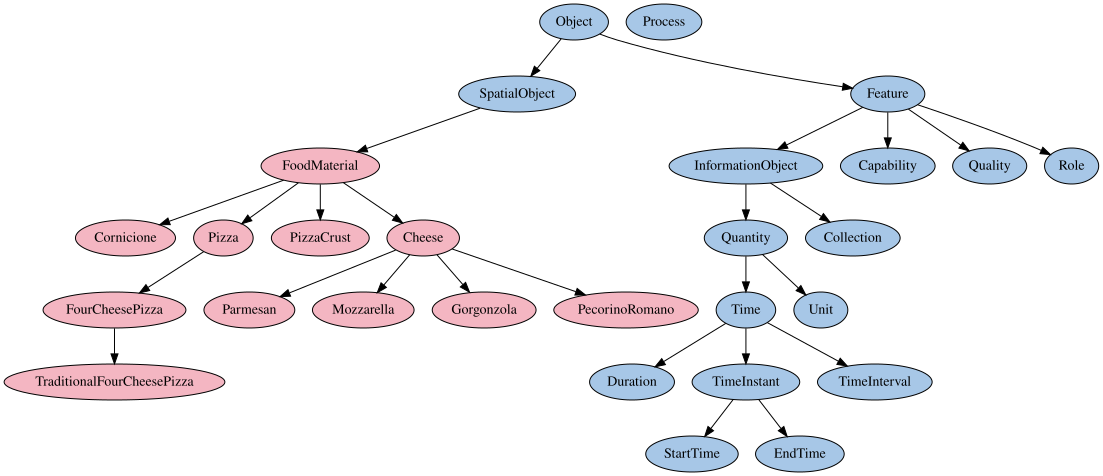

In [26]:
pizza_class_tree = get_color_tree([sulo, pizza])
print("Pizza Class hierarchy")
display(pizza_class_tree)  # Class hierarchy

## Additional Exercises

### Exercise 1 — `MargheritaPizza`
A classic Margherita pizza consists of exactly one `PizzaCrust`, one `PizzaSauce` (tomato), and one `Mozzarella` topping — and nothing else. Define `TomatoSauce` as a subclass of `PizzaSauce`. Then define `MargheritaPizza` as an equivalent class using cardinality and universal restrictions. Run the reasoner and verify that a `MargheritaPizza` is classified as a `FourCheesePizza` — or explain why it is not.


## Minimum and Maximum Cardinality

So far we have used `exactly` (both a lower and an upper bound) and `some` (at least one, no upper bound). OWL also provides `min` and `max` for one-sided bounds:

| Restriction | Meaning |
|---|---|
| `prop.min(n, C)` | at least *n* instances of C |
| `prop.max(n, C)` | at most *n* instances of C |
| `prop.exactly(n, C)` | exactly *n* instances of C |

Unlike `exactly`, `min` and `max` are **open-ended**: `min(3)` does not prevent there being 10; `max(6)` does not require there to be any. Use them when the domain genuinely has only one bound.

In [27]:
with pizza:
    class LoadedPizza(Pizza):
        """A pizza with at least 3 toppings and at most 6."""
        label = [locstr("loaded pizza", "en")]
        is_a = [sulo.hasDirectPart.min(3, FoodMaterial),
                sulo.hasDirectPart.max(6, FoodMaterial)]

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])
print("LoadedPizza is_a:", LoadedPizza.is_a)

Ontology consistent: True
Inconsistent classes: []
LoadedPizza is_a: [pizza.Pizza, sulo.hasDirectPart.min(3, pizza.FoodMaterial), sulo.hasDirectPart.max(6, pizza.FoodMaterial)]


## Exercise 2 — Vegetarian pizza
Define `VegetableIngredient` as a subclass of `FoodMaterial`. Define `PepperIngredient`, `MushroomIngredient`, and `ArtichokeIngredient` as disjoint subclasses of `VegetableIngredient`. Define `VegetarianPizza` as a `Pizza` whose `hasDirectPart` is restricted with `only` to `VegetableIngredient | PizzaCrust | PizzaSauce`. Define `PepperoniIngredient` as a subclass of `FoodMaterial`, disjoint from `VegetableIngredient`, `PizzaCrust`, and `PizzaSauce`. Then define `PepperoniPizza` as a subclass of `VegetarianPizza` that also requires a `PepperoniIngredient` part. Show the reasoner detects inconsistency.


---

## Summary

This notebook built the foundation of the pizza ontology step by step, introducing the core OWL engineering concepts needed for the notebooks that follow.

### What we built

| Class | Kind | Key axiom |
|---|---|---|
| `FoodMaterial`, `Pizza`, `PizzaCrust`, `PizzaSauce` | Primitive | `SubClassOf sulo:SpatialObject` |
| `Cornicione`, `OliveOil` | Primitive | `SubClassOf FoodMaterial` |
| `Cheese`, `Mozzarella`, `Gorgonzola`, `Parmesan`, `PecorinoRomano` | Primitive | Cheese hierarchy + `AllDisjoint` |
| `FourCheesePizza` | Defined | `equivalent_to Pizza & hasDirectPart.exactly(4, Cheese)` |
| `TraditionalFourCheesePizza` | Defined | `equivalent_to` with four `exactly(1, ...)` + `only` |
| `ProsciuttoMozzarellaPizza`, `MargheritaPizza` | Defined | Full closed-world pattern |
| `ThinCrustPizza` | Defined | `hasDirectPart.exactly(1, ThinCrust)` |
| `LoadedPizza` | Primitive | `hasDirectPart.min(3, ...)` + `max(6, ...)` |
| `VegetarianPizza` | Defined | `hasDirectPart.only(VegetableIngredient \| PizzaCrust \| PizzaSauce)` |

### Key concepts

**`hasPart` vs `hasDirectPart`** — `hasPart` is transitive and reflexive, which makes cardinality restrictions on it illegal in OWL DL. SULO provides `hasDirectPart` as a non-transitive sub-property for exactly this purpose. Because `hasDirectPart ⊑ hasPart`, all `hasDirectPart` assertions are inherited by `hasPart`, and `INDIRECT_hasPart` queries traverse the full transitive closure.

**Cardinality restrictions** — `some` (∃, at least one), `min` (≥ n), `max` (≤ n), and `exactly` (= n) constrain how many fillers a property slot can have. For identity-defining parts like a pizza crust, `exactly(1)` is the right choice. `min`/`max` are appropriate when only one bound exists.

**Defined classes and `equivalent_to`** — a class defined with `equivalent_to` is a *necessary and sufficient* condition: the reasoner can classify any individual or class that satisfies the expression. A class defined with only `is_a` is *necessary* but not sufficient; the reasoner will not infer membership automatically.

**Open World Assumption** — the reasoner never assumes that two things are distinct unless told so. To make a defined class *closed*, assert `AllDisjoint` on the relevant fillers and add a universal restriction (`only`) to rule out anything else. Without both, classification will fail silently.

### What comes next

Notebook 02 introduces **qualities** and **quantities** — how to represent intrinsic properties like spiciness categorically (e.g. `SpicyHot`) and numerically (e.g. Scoville heat units ≥ 500 000), and how to bridge the two definitions so a single reasoner can classify both.
